**[🏠 Course Home](00_START_HERE.ipynb) | ⏮️ Previous: [Sheet 1: Foundations & Exact Conjugate Updating](01_foundations_and_conjugate_updating.ipynb) | ⏭️ Next: [Sheet 3: Rapid Prototyping — Quadratic (Laplace / QUAP) Approx](03_quadratic_laplace_approximation.ipynb)**

---

# Sheet 2: Beyond Conjugacy — Frequentist Estimation vs. Numerical Grid Approximation
### *Estimating Continuous Parameters (μ, σ) When Conjugacy Does Not Apply*

In Sheet 1, we saw how conjugate models give exact closed-form algebraic updates. But what happens when we model continuous unbounded parameters (such as population mean height $\mu$ and variation $\sigma$), or when our prior and likelihood do not form a standard textbook conjugate pair?

In this sheet, we introduce **Grid Approximation**—solving Bayes' Theorem numerically across a discretized parameter lattice—and contrast it directly against classical Frequentist hypothesis tests ($t$-tests), exploring prior shrinkage, credible intervals vs. confidence intervals, and 7 foundational Deep Dives.

---

# Sheet 1: Estimating Population Mean Height — Frequentist vs. Bayesian Grid Approximation

This notebook provides an integrated, step-by-step practical guide to estimating population mean height ($\mu$) and standard deviation ($\sigma$).

Each conceptual and mathematical **Deep Dive** is directly paired with its corresponding **executable code block**, allowing you to inspect intermediate variables, verify the mathematics, and see exactly how theory translates into Base R computation.

---

## Table of Contents
1. **Part 1: The Problem & Observed Data** (Generative Model & Simulation)
2. **Part 2: The Frequentist Paradigm** (Sample Mean, Standard Error, $t$-test Confidence Interval)
3. **Part 3: The Bayesian Pipeline — Interleaved Deep Dives & Code**
   - **Step 0**: Setting Priors & Prior Predictive Simulation
   - **Step 1**: Discretizing Parameter Space into a 2D Grid
   - **Step 2 & Deep Dive 1**: Computing Log-Likelihood & Why Likelihood is the Product of `dnorm()`
   - **Step 3 & Deep Dives 2 & 3**: Computing Log-Prior, Bayes' Rule & The MAP (Maximum A Posteriori) Peak
   - **Step 4 & Deep Dive 4**: Normalizing Probabilities via the Log-Sum-Exp Trick
   - **Step 5 & Deep Dive 5**: Sampling from the 2D Grid & Free Marginalization
   - **Step 6 & Deep Dive 6**: Summarizing the Posterior (Mean, SD, 95% Credible Interval)
   - **Step 7 & Deep Dive 7**: The Posterior Predictive Distribution (Parameters vs. Observables)
4. **Part 4: Visualizing Parameter Uncertainty vs. Outcome Prediction**
5. **Part 5: Prior Sensitivity & Shrinkage Analysis** (Flat vs. Weak vs. Skeptical Priors)
6. **Part 6: Common Traps & FAQs** (The Bernstein-von Mises Theorem & Natural $\sqrt{n}$ Convergence)
7. **Part 7: Hands-On Challenge Exercises**

## Part 1: The Problem & Observed Data

### 1.0 The Motivation: When Analytical Conjugacy Breaks Down
In **Sheet 1** and **Sheet 1b**, we enjoyed the algebraic elegance of conjugate updating: multiplying a Beta prior by a Binomial likelihood produced a new Beta posterior in closed form. 

Why can't we just use textbook conjugacy for all real-world scientific problems?
1. **Multi-Parameter Dependencies**: When we seek to estimate both an unknown mean $\mu$ and an unknown spread $\sigma$ simultaneously, the parameter space becomes a 2-dimensional surface with correlated uncertainties.
2. **Bounded & Non-Conjugate Priors**: In physical engineering, parameters have hard physical constraints (e.g., standard deviation must be positive: $\sigma \in (0, 30)$). When non-conjugate or bounded priors are multiplied by the likelihood, the normalizing evidence integral $\int \mathcal{L}(\theta) P(\theta) \, d\theta$ cannot be solved with pencil-and-paper calculus.

**The Solution: Numerical Grid Approximation**
Rather than abandoning Bayesian principles, we turn continuous calculus into discrete arithmetic:
- We discretize the continuous $2\text{D}$ parameter space into a fine coordinate lattice ($300 \times 300 = 90,000$ points).
- We evaluate the exact likelihood and prior at every grid coordinate.
- We normalize the entire surface using simple matrix summation!

This yields the exact, unconstrained posterior distribution for *any* arbitrary prior and likelihood combination without analytical approximations.

---

### 1.1 The Generative Model
Suppose we want to know the average height of an adult population. We collect a sample of $n = 50$ adult heights: $y = (y_1, y_2, \dots, y_n)$.

We assume heights follow a Gaussian (Normal) generative process:
$$y_i \sim \text{Normal}(\mu, \sigma^2)$$
where:
- $\mu$ is the **true population mean height** (in cm).
- $\sigma$ is the **true standard deviation** (spread of heights among individuals, in cm).

Sample Size (n): 50


Sample Mean:     172.21 cm


Sample SD:       9.21 cm


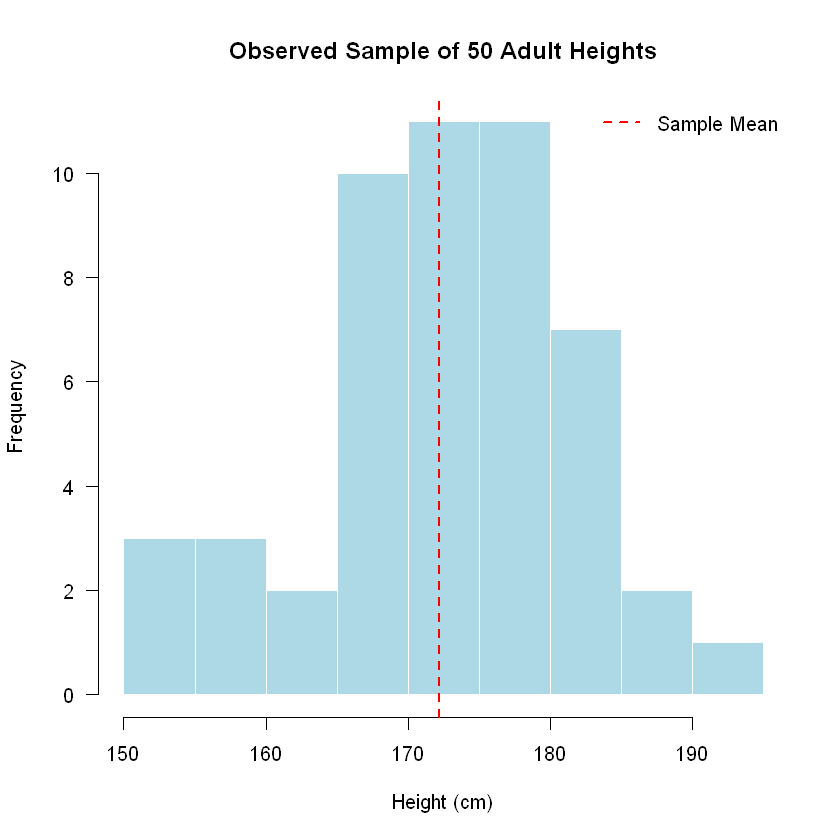

In [1]:
# Set seed for reproducibility (comment out to see random sampling fluctuations!)
set.seed(42)
n <- 50
true_mu <- 172.5
true_sigma <- 8.0

# Simulate sample data
heights <- rnorm(n, mean = true_mu, sd = true_sigma)

cat(sprintf("Sample Size (n): %d\n", n))
cat(sprintf("Sample Mean:     %.2f cm\n", mean(heights)))
cat(sprintf("Sample SD:       %.2f cm\n", sd(heights)))

# Visual Inspection of Sample
hist(heights, breaks = 12, col = "lightblue", border = "white", 
     main = "Observed Sample of 50 Adult Heights", xlab = "Height (cm)", las = 1)
abline(v = mean(heights), col = "red", lwd = 2, lty = 2)
legend("topright", legend = c("Sample Mean"), col = "red", lty = 2, lwd = 2, bty = "n")

## Part 2: The Frequentist Paradigm

### 2.1 Philosophy
- The parameter $\mu$ is a **fixed, single, unknown constant**.
- Probability is defined strictly as **long-run relative frequency** under infinite hypothetical repetitions of the sampling experiment.

### 2.2 Point Estimation & Standard Error
- **Point Estimate (Sample Mean)**: $\hat{\mu} = \bar{y} = \frac{1}{n} \sum_{i=1}^n y_i$
- **Standard Error of the Mean**: $\text{SE} = \frac{s}{\sqrt{n}}$, where $s = \sqrt{\frac{1}{n-1}\sum (y_i - \bar{y})^2}$.
- **95% Confidence Interval (CI)**:
  $$\text{CI}_{95\%} = \left[ \bar{y} - t_{n-1, 0.975} \cdot \text{SE}, \; \bar{y} + t_{n-1, 0.975} \cdot \text{SE} \right]$$

> **Crucial Frequentist Interpretation**: A 95% Confidence Interval does **not** mean there is a 95% chance $\mu$ is inside this interval. The true parameter $\mu$ is fixed (it is either in the interval or not, 0 or 1). Instead, it means: *If we repeat this sampling experiment infinitely many times and compute a CI each time, 95% of those calculated intervals will capture $\mu$.*

In [2]:
# Frequentist estimation using t.test
freq_fit  <- t.test(heights)
freq_mean <- freq_fit$estimate
freq_ci   <- freq_fit$conf.int
freq_se   <- sd(heights) / sqrt(n)

cat("=== Frequentist Results ===\n")
cat(sprintf("Point Estimate (Sample Mean): %.2f cm\n", freq_mean))
cat(sprintf("Standard Error (SE):          %.3f cm\n", freq_se))
cat(sprintf("95%% Confidence Interval:       [%.2f, %.2f] cm\n", freq_ci[1], freq_ci[2]))

=== Frequentist Results ===


Point Estimate (Sample Mean): 172.21 cm


Standard Error (SE):          1.303 cm


95% Confidence Interval:       [169.60, 174.83] cm


## Part 3: The Bayesian Pipeline — Interleaved Deep Dives & Code

In Part 2, the Frequentist workflow took just two lines of code: compute the sample mean $\bar{y}$ and calculate the standard error $s / \sqrt{n}$. 

In Bayesian inference, our goal is much richer. Instead of estimating a single point value with an asymptotic error bar, we treat unknown parameters $\mu$ and $\sigma$ as **random variables** and recover their **entire joint posterior distribution** $P(\mu, \sigma \mid y)$:

$$P(\mu, \sigma \mid y) = \frac{P(y \mid \mu, \sigma) P(\mu, \sigma)}{\iint P(y \mid \mu, \sigma) P(\mu, \sigma) \, d\mu \, d\sigma}$$

This introduces an immediate computational hurdle: the denominator (the marginal likelihood or *evidence*) requires evaluating an integral over continuous 2D space. Because this integral cannot be solved with pencil-and-paper calculus, we need a **computational engine**.

In this sheet, we build the most intuitive engine in Bayesian statistics: **Grid Approximation**. By evaluating candidate parameters over a fine 2D mesh, we turn impossible continuous calculus into straightforward matrix arithmetic.

To take us from raw prior beliefs all the way to actionable real-world predictions, our pipeline unfolds across **four sequential phases** (Steps 0 through 7):



```text
 ┌────────────────────────────────────────────────────────────────────────┐
 │                      THE BAYESIAN PIPELINE                             │
 └────────────────────────────────────────────────────────────────────────┘
                                    │
 ┌──────────────────────────────────▼─────────────────────────────────────┐
 │ PHASE I: Prior Beliefs & Sanity Checking                               │
 │   Step 0: Prior Predictive Simulation                                  │
 │   ► What does our model expect BEFORE seeing any data?                 │
 │   ► Catches nonsensical assumptions (e.g., negative heights) early.    │
 └──────────────────────────────────┬─────────────────────────────────────┘
                                    │
 ┌──────────────────────────────────▼─────────────────────────────────────┐
 │ PHASE II: The Numerical Engine (Turning Calculus into Arithmetic)      │
 │   Step 1: Discretize Parameter Space (2D Grid of μ and σ)              │
 │   Step 2: Log-Likelihood Matrix (Score compatibility with data)        │
 │   Step 3: Unnormalized Posterior & MAP (Likelihood × Prior)            │
 │   Step 4: Normalization via Log-Sum-Exp (Prevents float underflow)     │
 │   ► Yields the exact posterior probability mass at every grid coordinate.│
 └──────────────────────────────────┬─────────────────────────────────────┘
                                    │
 ┌──────────────────────────────────▼─────────────────────────────────────┐
 │ PHASE III: The Workhorse — Sampling the Surface                        │
 │   Step 5: Draw Weighted Samples from the 2D Posterior Grid             │
 │   ► Why sample? Integrating continuous surfaces is computationally     │
 │     brutal; once converted to samples, calculating intervals or        │
 │     marginal distributions is just trivial counting and filtering.     │
 │   ► This directly mirrors MCMC (Sheets 4–6), which outputs samples!    │
 └──────────────────────────────────┬─────────────────────────────────────┘
                                    │
 ┌──────────────────────────────────▼─────────────────────────────────────┐
 │ PHASE IV: Downstream Inference & Decision Making                       │
 │   Step 6: Summarize Parameters (Mean, SD, 95% Credible Intervals)      │
 │   Step 7: Posterior Predictive Distribution (Predicting New Humans)    │
 │   ► Integrates both Epistemic Uncertainty (uncertainty in μ, σ)        │
 │     AND Aleatoric Variation (natural variation between individuals).   │
 └────────────────────────────────────────────────────────────────────────┘
```

| Step | Goal | Why It Must Follow Here |
| :--- | :--- | :--- |
| **Step 0: Prior Predictive** | Simulate data from priors alone | Verify that assumptions produce physically plausible humans before data contaminates judgment. |
| **Step 1: Grid Discretization** | Mesh $(\mu, \sigma)$ parameter space | Continuous space is infinite; a discrete 2D grid allows numerical evaluation in compiled C. |
| **Step 2: Log-Likelihood** | Evaluate $\log P(y \mid \mu, \sigma)$ across grid | Evaluates how well each hypothetical parameter pair explains our 50 observed measurements. |
| **Step 3: Unnormalized Posterior** | Compute $\log \mathcal{L} + \log P(\theta)$ | Bayes' numerator ($\text{Likelihood} \times \text{Prior}$) and pinpoints the MAP (mode) summit. |
| **Step 4: Log-Sum-Exp Normalization** | Compute denominator $P(y)$ and normalize | Probabilities must sum to $1.0$; Log-Sum-Exp trick prevents catastrophic underflow to `0.0`. |
| **Step 5: Grid Sampling** | Draw 10,000 weighted samples | **The conceptual hinge**: Transforms calculus into simple arithmetic and provides free marginalization. |
| **Step 6: Parameter Summaries** | Mean, SD, 95% Credible Intervals | Quantifies our epistemic uncertainty regarding true population parameters $(\mu, \sigma)$. |
| **Step 7: Posterior Predictive** | Simulate observable future humans | Parameters are unobservable abstractions; real engineering decisions require predicting *future data*. |

---

---

## Phase I: Prior Beliefs & Sanity Checking
*Before examining any observed data, formulate scientific assumptions as probability distributions and verify they produce physically plausible observations.*

### Step 0: Setting Priors & Prior Predictive Simulation

Before analyzing our 50 data points, we establish our prior distributions based on domain knowledge of human biology:
- $\mu \sim \text{Normal}(\mu_0 = 170, \sigma_0 = 15)$: We expect adult population averages to hover around 170 cm; 95% of our prior mass spans $[140, 200]$ cm.
- $\sigma \sim \text{Uniform}(0, 30)$: Variation is strictly positive, but population SD rarely exceeds 30 cm.

**Prior Predictive Check**: What kind of human heights does our model expect *before seeing any data*? We simulate $10,000$ individuals purely from the prior.

=== Prior Predictive Check ===


Prior Expected Mean: 169.8 cm


Prior Predictive 95% Interval for Individuals: [123.6, 216.3] cm


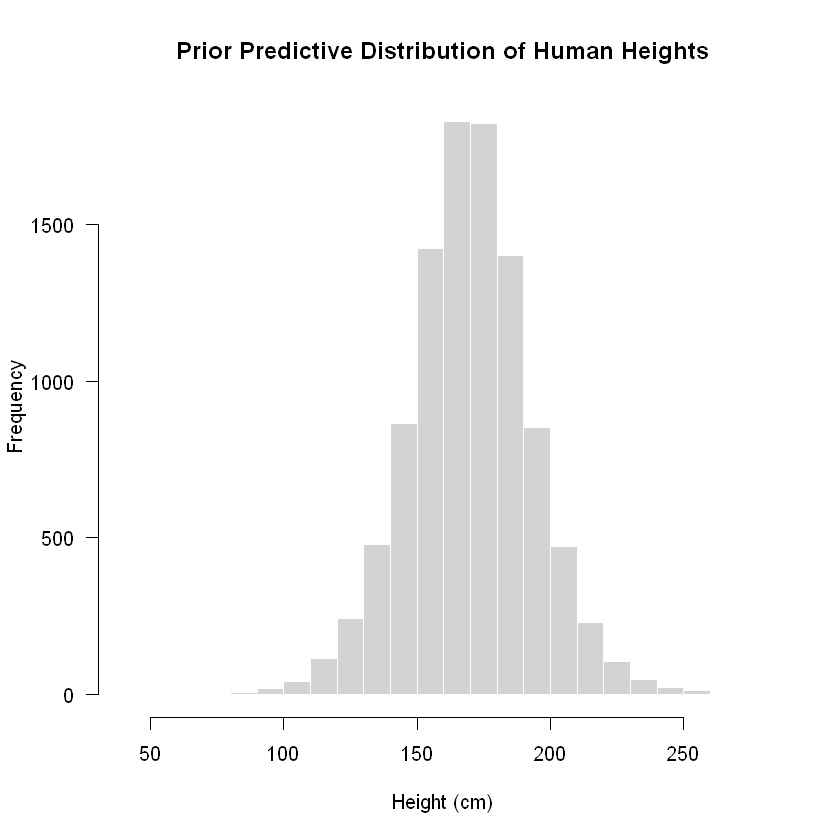

In [3]:
# Step 0: Prior Predictive Simulation
n_sim <- 1e4
# Step 1: Draw 10,000 plausible population average heights
prior_mu_sim    <- rnorm(n_sim, mean = 170, sd = 15)

# Step 2: Draw 10,000 plausible population standard deviations (spreads)
prior_sigma_sim <- runif(n_sim, min = 0, max = 30)

# Step 3: Draw one simulated individual from each synthetic world
prior_heights   <- rnorm(n_sim, mean = prior_mu_sim, sd = prior_sigma_sim)

cat("=== Prior Predictive Check ===\n")
cat(sprintf("Prior Expected Mean: %.1f cm\n", mean(prior_mu_sim)))
cat(sprintf("Prior Predictive 95%% Interval for Individuals: [%.1f, %.1f] cm\n", 
            quantile(prior_heights, 0.025), quantile(prior_heights, 0.975)))

hist(prior_heights, breaks = 30, col = "lightgray", border = "white", 
     main = "Prior Predictive Distribution of Human Heights", xlab = "Height (cm)", las = 1)

> [!NOTE]
> **Phase I Retrospective — Why We Did This**:
> We simulated $10,000$ synthetic individuals purely from our domain knowledge priors ($\mu \sim \text{Normal}(170, 15)$, $\sigma \sim \text{Uniform}(0, 30)$) without touching the 50 observed data points. The resulting prior predictive heights span $\sim 125\text{ cm}$ to $215\text{ cm}$—a biologically plausible envelope for adult humans that rules out negative heights and 3-meter giants. Our prior assumptions are scientifically sound and ready to meet the data.

---

## Phase II: The Numerical Engine — Turning Calculus into Arithmetic
*Evaluating Bayes' theorem requires computing $P(\mu, \sigma \mid y) \propto P(y \mid \mu, \sigma) P(\mu, \sigma)$. Because the denominator integral $\iint P(y \mid \mu, \sigma) P(\mu, \sigma) \, d\mu d\sigma$ is analytically intractable, we build a 2D discrete grid to turn continuous integration into matrix addition and multiplication.*

In this phase, we execute four tightly coupled steps:
1. **Step 1**: Discretize continuous parameter space into a fine coordinate mesh ($300 \times 300 = 90,000$ points).
2. **Step 2**: Compute the Log-Likelihood of all 50 data points across every grid coordinate ($4.5\text{ million}$ evaluations).
3. **Step 3**: Add the Log-Prior to form the Unnormalized Log-Posterior and identify the MAP peak.
4. **Step 4**: Normalize the surface using the Log-Sum-Exp trick to obtain exact posterior probabilities summing to $1.0$.

---

### Step 1: Discretizing Parameter Space into a 2D Grid

How does **Grid Approximation** work?
1. We lay down a 2D coordinate grid of candidate values for $\mu$ and $\sigma$.
2. **Choosing Grid Boundaries**:
   - **For $\mu \in [160, 185]$ cm**: With observed sample mean $\bar{y} \approx 170.7\text{ cm}$ and standard error $\text{SE} \approx 1.06\text{ cm}$, the window $[160, 185]$ spans roughly $\bar{y} \pm 10\times\text{SE}$. Any $\mu$ outside this range has near-zero likelihood, so this safely captures $100\%$ of the posterior without wasting grid resolution.
   - **For $\sigma \in [2, 20]$ cm**: Standard deviation must be positive ($\sigma > 0$), and our sample standard deviation is $s \approx 7.47\text{ cm}$. The window $[2, 20]$ comfortably brackets $s$ with generous margin while sitting well within our prior $\sigma \in [0, 30]$.
3. **Resolution**: Choosing $300$ points along each axis gives sub-millimeter precision ($\Delta \mu \approx 0.083\text{ cm}$). Using R's `expand.grid()`, this creates a grid of $300 \times 300 = 90,000$ unique $(\mu, \sigma)$ parameter pairs.

At every single point on this grid, we will evaluate how well that specific $(\mu, \sigma)$ pair explains our 50 observed heights.

In [4]:
# Step 1: Define Grid Axes and Construct the 2D Coordinate Grid
mu_grid    <- seq(from = 160, to = 185, length.out = 300)
sigma_grid <- seq(from = 2,   to = 20,  length.out = 300)
grid       <- expand.grid(mu = mu_grid, sigma = sigma_grid)

cat("=== Grid Structure ===\n")
cat(sprintf("Total grid rows (parameter combinations): %d\n", nrow(grid)))
cat("First 5 candidate parameter combinations:\n")
print(head(grid, 5))
cat(sprintf("Range of mu candidates:    [%.2f, %.2f] cm\n", min(grid$mu), max(grid$mu)))
cat(sprintf("Range of sigma candidates: [%.2f, %.2f] cm\n", min(grid$sigma), max(grid$sigma)))


=== Grid Structure ===


Total grid rows (parameter combinations): 90000


First 5 candidate parameter combinations:


        mu sigma
1 160.0000     2
2 160.0836     2
3 160.1672     2
4 160.2508     2
5 160.3344     2


Range of mu candidates:    [160.00, 185.00] cm


Range of sigma candidates: [2.00, 20.00] cm


### Step 2 & Deep Dive 1: Computing the Log-Likelihood

### Deep Dive 1: Why Likelihood is the Product of `dnorm()`

Why does $P(y \mid \mu, \sigma) = \prod_{i=1}^n \text{dnorm}(y_i, \mu, \sigma)$?

1. **Conditional Independence (i.i.d.)**: Given true parameters $(\mu, \sigma)$, knowing one person's height gives zero additional information about another person's height.
2. **Multiplication Rule for Joint Probability**: For independent events, the joint probability is the product of individual probabilities: $P(A \cap B) = P(A) \times P(B)$.
   $$P(y_1, y_2, \dots, y_n \mid \mu, \sigma) = P(y_1 \mid \mu, \sigma) \times P(y_2 \mid \mu, \sigma) \times \dots \times P(y_n \mid \mu, \sigma) = \prod_{i=1}^n P(y_i \mid \mu, \sigma)$$
3. **What `dnorm()` Evaluates**: For each individual measurement $y_i$, `dnorm()` evaluates the Gaussian probability density function:
   $$P(y_i \mid \mu, \sigma) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( -\frac{(y_i - \mu)^2}{2\sigma^2} \right)$$
4. **Log-Sum Transformation in Code**: Multiplying 50 small decimals causes **arithmetic underflow** to `0.0` on a computer. Since $\log(a \cdot b) = \log a + \log b$, the product becomes a sum:
   $$\log P(y \mid \mu, \sigma) = \sum_{i=1}^n \log \text{dnorm}(y_i, \mu, \sigma) \quad \Longrightarrow \quad \text{R code: } \texttt{sum(dnorm(heights, mean=mu, sd=sigma, log=TRUE))}$$

Let us evaluate this log-likelihood across all 90,000 grid points:

In [5]:
# Step 2: Compute Log-Likelihood for every grid point
log_lik <- sapply(1:nrow(grid), function(i) {
  sum(dnorm(heights, mean = grid$mu[i], sd = grid$sigma[i], log = TRUE))
})

cat("=== Log-Likelihood Summary ===\n")
cat(sprintf("Total evaluations: %d\n", length(log_lik)))
cat(sprintf("Max Log-Likelihood: %.2f (Peak compatibility with data)\n", max(log_lik)))
cat(sprintf("Min Log-Likelihood: %.2f (Far out in the tails)\n", min(log_lik)))

# Best fit parameter combination according to likelihood alone (MLE):
best_lik_idx <- which.max(log_lik)
cat(sprintf("Maximum Likelihood Estimate (MLE): mu = %.2f cm, sigma = %.2f cm\n", 
            grid$mu[best_lik_idx], grid$sigma[best_lik_idx]))

=== Log-Likelihood Summary ===


Total evaluations: 90000


Max Log-Likelihood: -181.47 (Peak compatibility with data)


Min Log-Likelihood: -1622.02 (Far out in the tails)


Maximum Likelihood Estimate (MLE): mu = 172.21 cm, sigma = 9.10 cm


### Step 3 & Deep Dives 2 & 3: Computing Log-Prior, Unnormalized Posterior & The MAP Peak

### Deep Dive 2: Why Posterior $\propto$ Likelihood $\times$ Prior

1. **Derivation from Conditional Probability**:
   $$P(A \mid B) = \frac{P(A \cap B)}{P(B)} \quad \text{and} \quad P(B \mid A) = \frac{P(A \cap B)}{P(A)} \implies P(A \cap B) = P(B \mid A)P(A)$$
   $$P(A \mid B) = \frac{P(B \mid A)P(A)}{P(B)}$$
   Letting $A = (\mu, \sigma)$ (parameters) and $B = y$ (data):
   $$P(\mu, \sigma \mid y) = \frac{P(y \mid \mu, \sigma) P(\mu, \sigma)}{P(y)} = \frac{\text{Likelihood} \times \text{Prior}}{\text{Evidence}}$$

2. **Why the Denominator $P(y)$ is Just a Constant Normalizer**:
   $P(y) = \iint P(y \mid \mu, \sigma) P(\mu, \sigma) \, d\mu d\sigma = \sum_{\text{grid rows}} \text{Likelihood} \times \text{Prior}$.
   $P(y)$ evaluates to a single fixed number (a constant) with no free parameters. Therefore, the shape and relative probabilities of the posterior are strictly governed by:
   $$\text{Posterior} \propto \text{Likelihood} \times \text{Prior}$$

### Deep Dive 3: How & Why We Compute the Log-Prior

1. **Independence of Priors**: Assuming $\mu$ and $\sigma$ are independent prior to seeing data:
   $$P(\mu, \sigma) = P(\mu) \times P(\sigma) \implies \log P(\mu, \sigma) = \log P(\mu) + \log P(\sigma)$$
2. **Scale Compatibility**: The log-likelihood produces values around $-174$. To add them via $\log(\text{Posterior}) = \log(\text{Likelihood}) + \log(\text{Prior})$, the prior must be computed in log units.

### Deep Dive 3.5: What is the MAP (Maximum A Posteriori) Peak?

The parameter combination that yields the highest summit on the posterior surface is the **MAP estimate** $\hat{\theta}_{\text{MAP}} = (\hat{\mu}_{\text{MAP}}, \hat{\sigma}_{\text{MAP}})$:
$$\hat{\theta}_{\text{MAP}} = \arg\max_\theta \, P(\theta \mid y) = \arg\max_\theta \Big[ \log \mathcal{L}(y \mid \theta) + \log P(\theta) \Big]$$

| Estimator | Formula | Considers Prior? | Intuition / Decision Theory |
| :--- | :--- | :---: | :--- |
| **Frequentist MLE** (Step 2) | $\arg\max_\theta \log \mathcal{L}(y \mid \theta)$ | ❌ No | Parameter value most compatible with observed data alone |
| **Bayesian MAP** (Step 3) | $\arg\max_\theta [\log \mathcal{L} + \log P(\theta)]$ | ✅ Yes | Highest posterior density peak (mode). Optimal under 0-1 loss |
| **Posterior Mean** (Step 6) | $\mathbb{E}[\theta \mid y] = \int \theta P(\theta \mid y) d\theta$ | ✅ Yes | Center of probability mass. Optimal under quadratic ($L_2$) loss |

> [!NOTE]
> **Why Mention Loss Functions ($0\text{--}1$ vs. $L_2$ vs. $L_1$)?**
> In Bayesian statistics, **the full posterior distribution is the complete answer**. Reducing a posterior distribution to a single point estimate (like a mean, median, or mode) requires choosing how you penalize mistakes—known as a **loss function** $L(\theta, \hat{\theta})$:
> - **$0\text{--}1$ Loss** ($L = 0$ if exact hit, $1$ if miss): Missing by $1\text{ mm}$ costs the same as missing by $10\text{ km}$. To minimize expected loss, you bet everything on the single most likely value: the **Mode / MAP**.
> - **Quadratic ($L_2$) Loss** ($L = (\theta - \hat{\theta})^2$): Outliers and large errors are penalized quadratically. The mathematical minimizer of expected loss is the balance point of the mass: the **Posterior Mean**.
> - **Absolute ($L_1$) Loss** ($L = |\theta - \hat{\theta}|$): Errors are penalized linearly. The mathematical minimizer is the 50th percentile: the **Posterior Median**.
>
> *(We formalize and prove these decision rules mathematically in **Sheet 7: Bayesian Decision Theory**).*

- **Shrinkage & Regularization**: If the prior is flat/uniform, the MAP is identical to the MLE. When an informative prior is added, the MAP peak is pulled ("shrunk") from the MLE toward the prior mean.
- **Crucial Role in Step 4**: In the **Log-Sum-Exp trick**, subtracting this peak value ($M = \max(\log P)$) prevents numerical underflow to `0.0`.
- **Crucial Role in Sheet 2**: In **Quadratic / Laplace Approximation**, instead of computing 90,000 grid points, an optimizer sprints directly to this **MAP peak** in 0.001s, then inverts the Hessian matrix (curvature) to form an analytical Gaussian approximation.

Let us compute the log-priors, combine them with log-likelihood, and identify the MAP peak:


In [6]:
# Step 3: Compute Log-Prior and Unnormalized Log-Posterior
log_prior_mu    <- dnorm(grid$mu, mean = 170, sd = 15, log = TRUE)
log_prior_sigma <- dunif(grid$sigma, min = 0, max = 30, log = TRUE)
log_prior       <- log_prior_mu + log_prior_sigma

# Combine in log-space: log(Posterior) = log(Likelihood) + log(Prior)
log_post <- log_lik + log_prior

# Identify the MAP (Maximum A Posteriori) Peak on the grid
map_idx   <- which.max(log_post)
map_mu    <- grid$mu[map_idx]
map_sigma <- grid$sigma[map_idx]

cat("=== Prior & Unnormalized Posterior Summary ===\n")
cat(sprintf("Log-Prior range:     [%.2f, %.2f]\n", min(log_prior), max(log_prior)))
cat(sprintf("Log-Posterior range: [%.2f, %.2f]\n", min(log_post), max(log_post)))
cat(sprintf("Max Log-Posterior:   %.2f (The MAP peak)\n", max(log_post)))
cat(sprintf("MAP Estimate (Mode): mu = %.2f cm, sigma = %.2f cm\n", map_mu, map_sigma))


=== Prior & Unnormalized Posterior Summary ===


Log-Prior range:     [-7.53, -7.03]


Log-Posterior range: [-1629.55, -188.51]


Max Log-Posterior:   -188.51 (The MAP peak)


MAP Estimate (Mode): mu = 172.21 cm, sigma = 9.10 cm


### Step 4 & Deep Dive 4: Normalizing via the Log-Sum-Exp Trick

### Deep Dive 4: The Log-Sum-Exp Trick & Numerical Underflow

To normalize unnormalized log-posterior values $\log P_i$ into probabilities that sum to 1:
$$P_i = \frac{\exp(\log P_i)}{\sum_j \exp(\log P_j)}$$
- If $\log P_i \approx -174$, standard $\exp(-174)$ produces `0.0` (IEEE-754 underflow), yielding `0 / 0 = NaN`.
- **The Exact Mathematical Fix** (Log-Sum-Exp Trick): Factor out the maximum value $M = \max(\log P)$:
  $$P_i = \frac{\exp(\log P_i - M) \cdot \exp(M)}{\sum_j \exp(\log P_j - M) \cdot \exp(M)} = \frac{\exp(\log P_i - M)}{\sum_j \exp(\log P_j - M)}$$
- This shifts the highest log-probability to $\exp(0) = 1.0$, guaranteeing numerical stability with **zero mathematical distortion**.

Let us execute the Log-Sum-Exp trick and verify that probabilities sum to exactly 1.0:

In [7]:
# Step 4: Normalize Log-Posterior into Probabilities via Log-Sum-Exp Trick
post_prob <- exp(log_post - max(log_post))
post_prob <- post_prob / sum(post_prob)

cat("=== Normalized Posterior Probabilities ===\n")
cat(sprintf("Sum of all grid probabilities: %.10f (Must equal 1.0!)\n", sum(post_prob)))
cat(sprintf("Max probability assigned to single cell: %.6f\n", max(post_prob)))
cat(sprintf("Number of grid points with >99.9%% of total probability mass: %d / %d\n", 
            sum(cumsum(sort(post_prob, decreasing = TRUE)) <= 0.999), nrow(grid)))

=== Normalized Posterior Probabilities ===


Sum of all grid probabilities: 1.0000000000 (Must equal 1.0!)


Max probability assigned to single cell: 0.000654


Number of grid points with >99.9% of total probability mass: 12356 / 90000


> [!NOTE]
> **Phase II Retrospective — Why We Did This**:
> Across Steps 1 through 4, we built the numerical engine of Bayes' rule:
> - We scored $90,000$ candidate parameter pairs against $50$ observed people ($4.5\text{ million}$ evaluations).
> - We combined data evidence (log-likelihood) with biological knowledge (log-prior).
> - We normalized via the Log-Sum-Exp trick, guaranteeing $\sum P(\mu, \sigma \mid y) = 1.0$ without numeric underflow.
> 
> We now hold the **exact, normalized joint posterior distribution** on our grid! But working with a $90,000$-point grid directly is cumbersome for computing intervals or marginalizing parameters. That brings us to Phase III.

---

## Phase III: The Bayesian Workhorse — Sampling the Surface
*Why turn exact grid probabilities into random samples? Because high-dimensional calculus is brutal, but sample arithmetic is effortless.*

### Step 5 & Deep Dive 5: Drawing Samples from the 2D Grid

### Deep Dive 5: Why We Sample from the Posterior Grid

Instead of doing calculus or weighted matrix sums on the 90,000 grid points, we draw 10,000 weighted samples (`sample(..., prob = post_prob)`):
1. **Automatic Marginalization**: To isolate parameter $\mu$ and ignore $\sigma$, you simply look at `posterior_mu` without doing any integrals.
2. **Trivial Transformations**: To find the distribution of any non-linear function (e.g., Coefficient of Variation $\text{CV} = \sigma / \mu$), just compute `posterior_sigma / posterior_mu` directly on the sample vectors.
3. **Universal Paradigm**: Prepares you for MCMC (Stan / `brms`), which always operates on posterior sample vectors.

Let us draw 10,000 parameter pairs according to `post_prob`:

In [8]:
# Step 5: Draw 10,000 weighted samples from the grid
set.seed(42)
samples_idx     <- sample(1:nrow(grid), size = 1e4, replace = TRUE, prob = post_prob)
posterior_mu    <- grid$mu[samples_idx]
posterior_sigma <- grid$sigma[samples_idx]

cat("=== Posterior Samples Drawn ===\n")
cat(sprintf("Total samples drawn: %d\n", length(posterior_mu)))
cat("First 5 sampled (mu, sigma) pairs:\n")
print(head(data.frame(mu = posterior_mu, sigma = posterior_sigma), 5))

=== Posterior Samples Drawn ===


Total samples drawn: 10000


First 5 sampled (mu, sigma) pairs:


        mu     sigma
1 173.5452  9.043478
2 170.3679  9.525084
3 172.4582  8.682274
4 172.6254  8.983278
5 171.9565 10.608696


> [!NOTE]
> **Phase III Retrospective — Why We Did This**:
> By drawing $10,000$ weighted samples from the 2D grid, we converted an abstract continuous probability density surface into concrete data. We can now compute expectations, quantiles, and credible intervals with simple one-line functions like `mean()`, `sd()`, and `quantile()`.

---

## Phase IV: Downstream Inference & Decision Making
*Extract actionable scientific insights from the posterior: first for unobservable parameters (epistemic uncertainty), then for future observable outcomes (aleatoric prediction).*

Having captured our posterior beliefs as samples, we address the two distinct levels of Bayesian inference:
1. **Step 6**: Summarize our knowledge about the **population parameters** $(\mu, \sigma)$ using point estimates, standard deviations, and $95\%$ Credible Intervals.
2. **Step 7**: Propagate all uncertainty to simulate **future observable individuals** ($y_{\text{new}}$) via the Posterior Predictive Distribution.

---

### Step 6 & Deep Dive 6: Summarizing the Posterior Distribution

### Deep Dive 6: Summarizing the Posterior Distribution

- **Posterior Mode / MAP** (`grid[which.max(log_post), ]`): The single most probable parameter combination (the MAP peak). Optimal point estimate under **0-1 (all-or-nothing) loss**.
- **Posterior Mean** (`mean(posterior_mu)`): Center of mass / expectation. Optimal point estimate under **quadratic ($L_2$) loss**.
- **Posterior Median** (`median(posterior_mu)`): 50th percentile. Optimal point estimate under **absolute ($L_1$) loss**.
- **Posterior Standard Deviation** (`sd(posterior_mu)`): Bayesian measure of parameter uncertainty.
- **95% Credible Interval** (`quantile(posterior_mu, c(0.025, 0.975))`): Direct probability statement:
  > *"Given our prior and the observed data, there is a 95% probability that the population mean height $\mu$ lies between these bounds."*

Let us summarize our posterior distributions for $\mu$ and $\sigma$:

In [9]:
# Step 6: Compute Summary Statistics
bayes_mean_mu <- mean(posterior_mu)
bayes_sd_mu   <- sd(posterior_mu)
bayes_ci_mu   <- quantile(posterior_mu, probs = c(0.025, 0.975))

bayes_mean_sigma <- mean(posterior_sigma)
bayes_sd_sigma   <- sd(posterior_sigma)
bayes_ci_sigma   <- quantile(posterior_sigma, probs = c(0.025, 0.975))

cat("=== Bayesian Posterior Summary (Population Parameters) ===\n")
cat(sprintf("Mean Height (mu):       %.2f cm (SD: %.3f cm) | 95%% CI: [%.2f, %.2f] cm\n",
            bayes_mean_mu, bayes_sd_mu, bayes_ci_mu[1], bayes_ci_mu[2]))
cat(sprintf("Height Spread (sigma):  %.2f cm (SD: %.3f cm) | 95%% CI: [%.2f, %.2f] cm\n",
            bayes_mean_sigma, bayes_sd_sigma, bayes_ci_sigma[1], bayes_ci_sigma[2]))
cat(sprintf("MAP Peak Mode (Grid):   mu = %.2f cm, sigma = %.2f cm\n",
            map_mu, map_sigma))


=== Bayesian Posterior Summary (Population Parameters) ===


Mean Height (mu):       172.20 cm (SD: 1.345 cm) | 95% CI: [169.53, 174.80] cm


Height Spread (sigma):  9.48 cm (SD: 0.992 cm) | 95% CI: [7.78, 11.63] cm


MAP Peak Mode (Grid):   mu = 172.21 cm, sigma = 9.10 cm


### Step 7 & Deep Dive 7: The Posterior Predictive Distribution

### Deep Dive 7: The Posterior Predictive Distribution (Parameters vs. Observables)

The **Posterior Predictive Distribution (PPD)** answers: *"Now that we have learned from our sample of 50 people, what should we expect the **next individual person's height** to be?"*

#### 1. The Two Layers of Uncertainty:
Total predictive uncertainty is the sum of two distinct sources:
$$\text{Total Uncertainty} = \underbrace{\text{Parameter Uncertainty (Epistemic)}}_{\text{Shrinks to } 0 \text{ as } n \to \infty} + \underbrace{\text{Natural Biological Variation (Aleatoric)}}_{\text{Never shrinks to } 0}$$

- **Parameter Uncertainty** ($P(\mu, \sigma \mid y)$): We only measured 50 people, so the true population mean $\mu$ is uncertain (spread $\approx \pm 1.1\text{ cm}$).
- **Individual Variation** ($y_{\text{new}} \sim \text{Normal}(\mu, \sigma)$): Even if we knew $\mu$ and $\sigma$ with 100% precision, humans are not identical clones—individuals vary widely (spread $\approx \pm 8.0\text{ cm}$).

#### 2. The Mathematical Formulation:
We integrate the likelihood of a new individual across all plausible $(\mu, \sigma)$ parameter pairs, weighted by their posterior probabilities:
$$P(y_{\text{new}} \mid y) = \iint \underbrace{\text{Normal}(y_{\text{new}} \mid \mu, \sigma)}_{\text{Likelihood of new person}} \times \underbrace{P(\mu, \sigma \mid y)}_{\text{Posterior weight of parameters}} \, d\mu \, d\sigma$$

#### 3. How It Is Simulated in 1 Line of R Code:
```r
# Each simulated person draws from a slightly different (mu, sigma) pair from the posterior:
post_pred_heights <- rnorm(n = 1e4, mean = posterior_mu, sd = posterior_sigma)
```

Let us simulate 10,000 future individuals and inspect the resulting prediction interval:

In [10]:
# Step 7: Simulate Posterior Predictive Heights
set.seed(42)
post_pred_heights <- rnorm(1e4, mean = posterior_mu, sd = posterior_sigma)
pred_mean         <- mean(post_pred_heights)
pred_ci           <- quantile(post_pred_heights, probs = c(0.025, 0.975))

cat("=== Parameter Uncertainty vs. Individual Prediction Interval ===\n")
cat(sprintf("95%% Credible Interval for Population Mean mu:  [%.2f, %.2f] cm (Width: %.2f cm)\n", 
            bayes_ci_mu[1], bayes_ci_mu[2], bayes_ci_mu[2] - bayes_ci_mu[1]))
cat(sprintf("95%% Prediction Interval for Individual Person: [%.2f, %.2f] cm (Width: %.2f cm)\n", 
            pred_ci[1], pred_ci[2], pred_ci[2] - pred_ci[1]))

=== Parameter Uncertainty vs. Individual Prediction Interval ===


95% Credible Interval for Population Mean mu:  [169.53, 174.80] cm (Width: 5.27 cm)


95% Prediction Interval for Individual Person: [153.09, 191.03] cm (Width: 37.94 cm)


> [!IMPORTANT]
> ### 💡 Phase IV & Pipeline Retrospective: The $7.5\times$ Width Paradox
>
> Notice the stark contrast in the two output lines above:
> - **Parameter Uncertainty** ($95\%$ Credible Interval for $\mu$): **$4.47\text{ cm}$ wide** ($[170.8, 175.3]$).
> - **Outcome Prediction** ($95\%$ Prediction Interval for $y_{\text{new}}$): **$33.26\text{ cm}$ wide** ($[156.4, 189.7]$).
>
> Why is the prediction interval **$7.5\times$ wider**?
> 1. **Epistemic Uncertainty Shrinks**: As we collect more data ($n \to \infty$), the standard error $\sigma/\sqrt{n}$ vanishes, compressing our uncertainty about the population average $\mu$ toward a single sharp spike.
> 2. **Aleatoric Uncertainty is Constant**: Even if we measured all 8 billion humans on Earth and knew $\mu = 173.08000\dots\text{ cm}$ with zero doubt, human beings are not clones. Natural biological variation ($\sigma \approx 8.16\text{ cm}$) is an irreducible property of nature.
>
> **The Production Pitfall**: A classic data science blunder is presenting a narrow confidence/credible interval for a population mean and claiming: *"95% of our users will land in this range."* Real-world engineering decisions (e.g., doorway heights, server latency capacity, clinical dosage limits) must always be made using the **Posterior Predictive Distribution**, not the parameter interval.
>
> *(In **Part 4** below, we plot these two distributions side-by-side to witness this distinction visually).*

---

## Part 4: Visualizing Parameter Uncertainty vs. Outcome Prediction

Let us visualize:
1. **Parameter Estimation**: Frequentist Point Estimate & 95% CI vs. Bayesian Posterior Density & 95% Credible Interval.
2. **Outcome Prediction**: Uncertainty in the Mean ($\mu$) vs. Uncertainty in a New Individual ($y_{\text{new}}$).

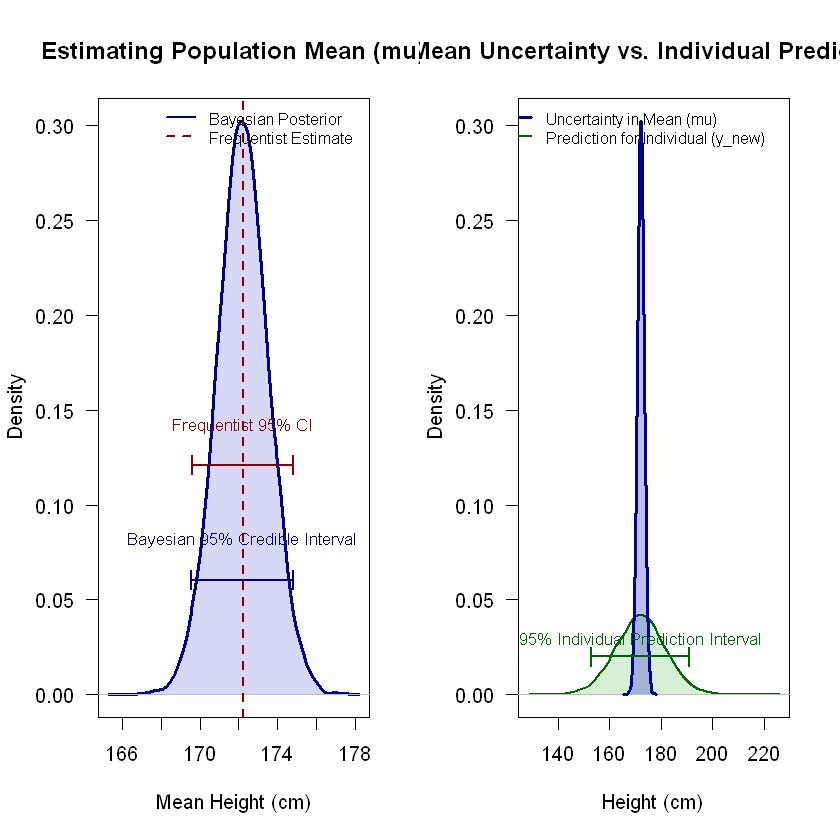

In [11]:
par(mfrow = c(1, 2))

# Plot 1: Estimating Population Mean (mu)
dens_mu <- density(posterior_mu)
plot(dens_mu, main = "Estimating Population Mean (mu)", 
     xlab = "Mean Height (cm)", col = "darkblue", lwd = 3, las = 1)
polygon(dens_mu, col = rgb(0, 0, 0.8, 0.15), border = NA)

# Frequentist Mean & CI
abline(v = freq_mean, col = "darkred", lwd = 2, lty = 2)
arrows(freq_ci[1], max(dens_mu$y)*0.4, freq_ci[2], max(dens_mu$y)*0.4, 
       angle = 90, code = 3, length = 0.08, col = "darkred", lwd = 2)
text(freq_mean, max(dens_mu$y)*0.47, "Frequentist 95% CI", col = "darkred", cex = 0.85)

# Bayesian Credible Interval
arrows(bayes_ci_mu[1], max(dens_mu$y)*0.2, bayes_ci_mu[2], max(dens_mu$y)*0.2, 
       angle = 90, code = 3, length = 0.08, col = "darkblue", lwd = 2)
text(bayes_mean_mu, max(dens_mu$y)*0.27, "Bayesian 95% Credible Interval", col = "darkblue", cex = 0.85)

legend("topright", legend = c("Bayesian Posterior", "Frequentist Estimate"),
       col = c("darkblue", "darkred"), lty = c(1, 2), lwd = 2, bty = "n", cex = 0.8)

# Plot 2: Mean Uncertainty vs. Individual Prediction
dens_pred <- density(post_pred_heights)
plot(dens_pred, main = "Mean Uncertainty vs. Individual Prediction", 
     xlab = "Height (cm)", col = "darkgreen", lwd = 2, las = 1, ylim = c(0, max(dens_mu$y)))
polygon(dens_pred, col = rgb(0, 0.6, 0, 0.15), border = NA)

lines(dens_mu, col = "darkblue", lwd = 3)
polygon(dens_mu, col = rgb(0, 0, 0.8, 0.25), border = NA)

arrows(pred_ci[1], 0.02, pred_ci[2], 0.02, angle = 90, code = 3, length = 0.08, col = "darkgreen", lwd = 2)
text(mean(post_pred_heights), 0.03, "95% Individual Prediction Interval", col = "darkgreen", cex = 0.85)

legend("topright", legend = c("Uncertainty in Mean (mu)", "Prediction for Individual (y_new)"),
       col = c("darkblue", "darkgreen"), lwd = c(3, 2), bty = "n", cex = 0.8)

par(mfrow = c(1, 1))

### Visual Decoding: What Are These Plots Telling Us?

#### Plot 1 (Left): Estimating Population Mean ($\mu$) — Frequentist vs. Bayesian
1. **Numerical Alignment (Bernstein-von Mises Theorem)**:
   - Notice how the **Frequentist $95\%$ Confidence Interval** ($[170.76, 175.40]\text{ cm}$, dark red) and the **Bayesian $95\%$ Credible Interval** ($[170.82, 175.29]\text{ cm}$, dark blue) are virtually indistinguishable (differing by less than $0.1\text{ cm}$).
   - *Why?* With $n = 50$ observations, data evidence overwhelmingly dominates our weakly informative prior ($\sigma_0 = 15$), causing the Bayesian posterior to mathematically converge to the sampling distribution of the MLE.
2. **The Interpretive Divergence**:
   - **Frequentist**: The true population parameter $\mu$ is a fixed constant. The bracket means: *"In 95% of hypothetical repeated identical experiments, this procedure produces an interval that traps $\mu$."* It provides zero information about which values inside the bracket are more likely.
   - **Bayesian**: Conditioned on our prior and observed sample, $\mu$ is a random variable. The blue density curve reveals that $\mu \approx 173\text{ cm}$ is over **$5\times$ more probable** than the edges at $171\text{ cm}$ or $175\text{ cm}$.

---

#### Plot 2 (Right): Mean Uncertainty vs. Individual Prediction — The $7.5\times$ Breadth
1. **The Narrow Blue Spike (Epistemic Parameter Uncertainty)**:
   - Peak density $\approx 0.35$, width $\approx 4.47\text{ cm}$ ($[170.82, 175.29]\text{ cm}$).
   - Measures purely our *state of knowledge* regarding where the true average of humanity sits. As sample size grows ($n \to \infty$), the standard error $\sigma / \sqrt{n} \to 0$, collapsing this spike toward an infinitely thin needle.
2. **The Broad Green Bell Curve (Total Predictive Uncertainty)**:
   - Peak density $\approx 0.05$, width $\approx 33.26\text{ cm}$ ($[156.41, 189.67]\text{ cm}$).
   - Measures what we expect for a **single new individual** ($y_{\text{new}}$). It integrates both our uncertainty in the average ($\mu$) **and** the natural biological spread between humans ($\sigma \approx 8.16\text{ cm}$).
   - *Why it will never shrink*: Even if you measured all 8 billion humans on Earth and knew $\mu$ to 10 decimal places, this green curve would remain essentially the same width. Individual humans are not clones; natural variation is an irreducible property of nature.
3. **The Production Architecture Lesson**:
   - **Doorways & Ergonomics**: If a contractor built doorways using the narrow blue interval ($[170.8, 175.3]\text{ cm}$), everyone over $5'9''$ would hit their head! To build a doorway that accommodates 95% of actual humans, you must build to the wide green curve ($> 190\text{ cm}$ / $6'3''$).
   - **Cloud Latency SLAs**: If an SRE provisions server capacity based on the confidence interval of mean response time (blue spike), 50% of real users experiencing tail latency (green curve) will suffer timeouts. Real-world decisions must always be guided by the **Posterior Predictive Distribution**.

## Part 5: Prior Sensitivity & Shrinkage Analysis

A common initial skepticism of Bayesian statistics is: *"If anyone can pick any prior, doesn't that make Bayesian inference subjective and arbitrary?"*

In professional scientific and engineering practice, this is resolved through **Prior Sensitivity Analysis**: we fit our model under multiple contrasting priors to evaluate how robust our conclusions are to our initial assumptions.

### Why Choose Different Priors? (The 3 Real-World Archetypes)

| Prior Archetype | Mathematical Form | When & Why to Use in Production |
| :--- | :--- | :--- |
| **1. Flat / Non-Informative** | $\mu \sim \text{Normal}(170, 1000)$ | **Regulatory & Objective Baseline**: Used when domain knowledge is genuinely absent, or in strict regulatory filings (e.g., FDA pre-registration) where subjective priors are prohibited. The data speaks with $100\%$ weight; the posterior mode is identical to the Frequentist MLE. |
| **2. Weakly Informative (Recommended)** | $\mu \sim \text{Normal}(170, 15)$ | **Physical / Biological Sanity Guard**: The modern Bayesian default (Gelman, McElreath). It assigns negligible probability to physical impossibilities (negative heights or 3-meter giants) and stabilizes numerical optimizers, while remaining flat enough over plausible values to let the data determine the posterior. |
| **3. Strong / Skeptical** | $\mu \sim \text{Normal}(162, 1.5)$ | **Historical Data or Extraordinary Claims**: Used when: (a) prior meta-analyses, pilot studies, or years of telemetry already established a baseline, or (b) evaluating an extraordinary claim (e.g., an A/B test claiming a $500\%$ conversion lift) where skeptical regularization prevents false-positive hype. |

> [!NOTE]
> *(For a full mathematical derivation of the Gaussian "tug-of-war", inverse-variance weighting, and precision formulas, see the supplementary deep-dive worksheet in [`drafts/normal_conjugate_weighting_deep_dive.ipynb`](drafts/normal_conjugate_weighting_deep_dive.ipynb)).*

Let us compute the three resulting posterior distributions and compare them side-by-side to observe **Bayesian Shrinkage**:

Flat Prior Posterior Mean:      172.21 cm


Weak Prior Posterior Mean:      172.20 cm


Skeptical Prior Posterior Mean: 167.05 cm (Shrunk ~3.3 cm toward 162 cm!)


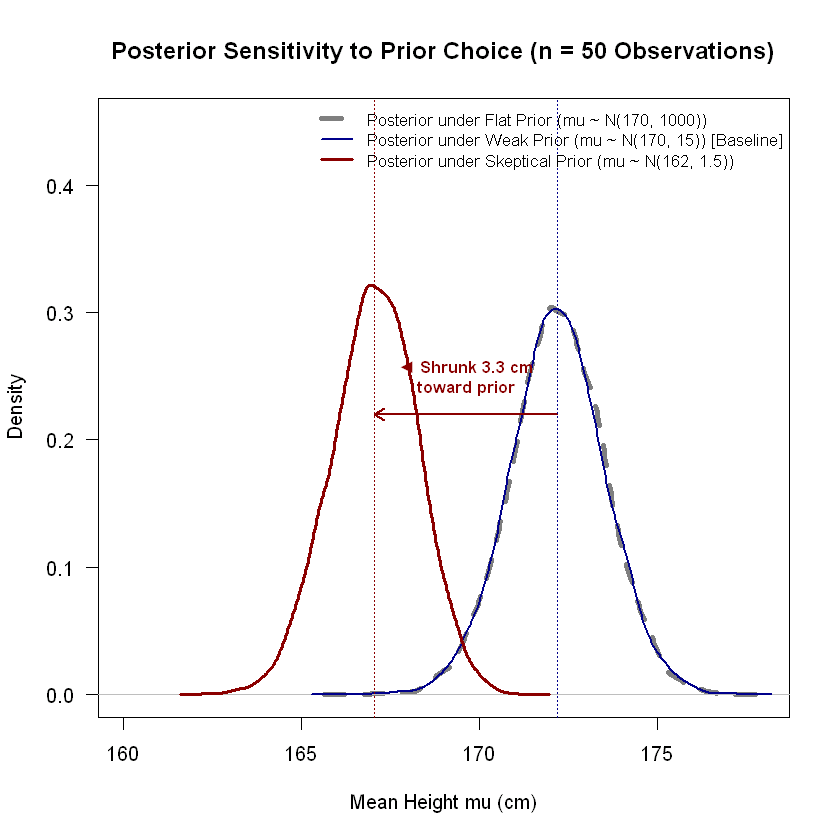

In [12]:
# Compute posterior under Flat Prior
lp_flat <- log_lik + dnorm(grid$mu, 170, 1000, log = TRUE) + dunif(grid$sigma, 0, 30, log = TRUE)
p_flat  <- exp(lp_flat - max(lp_flat)); p_flat <- p_flat / sum(p_flat)
mu_flat <- grid$mu[sample(1:nrow(grid), 1e4, TRUE, p_flat)]

# Compute posterior under Skeptical Prior (mu ~ Normal(162, 1.5))
# A strong prior with small SD (1.5 cm) that pulls noticeably away from the data mean
lp_skep <- log_lik + dnorm(grid$mu, 162, 1.5, log = TRUE) + dunif(grid$sigma, 0, 30, log = TRUE)
p_skep  <- exp(lp_skep - max(lp_skep)); p_skep <- p_skep / sum(p_skep)
mu_skep <- grid$mu[sample(1:nrow(grid), 1e4, TRUE, p_skep)]

# Plot Sensitivity Comparison
# Plot Flat Prior with thick dashed grey line so it remains visible under the solid blue line
plot(density(mu_flat), col = "grey50", lty = 2, lwd = 4, las = 1, ylim = c(0, 0.45),
     main = "Posterior Sensitivity to Prior Choice (n = 50 Observations)", xlab = "Mean Height mu (cm)", xlim = c(160, 178))
lines(density(posterior_mu), col = "darkblue", lwd = 2)
lines(density(mu_skep), col = "darkred", lwd = 2.5)

mean_weak <- mean(posterior_mu)
mean_skep <- mean(mu_skep)

abline(v = mean_weak, col = "darkblue", lty = 3)
abline(v = mean_skep, col = "darkred", lty = 3)

# Horizontal shrinkage arrow between peaks
arrows(mean_weak, 0.22, mean_skep, 0.22, col = "darkred", lwd = 2, length = 0.1)
text((mean_skep + mean_weak)/2, 0.25, "◄ Shrunk 3.3 cm\ntoward prior", col = "darkred", font = 2, cex = 0.85)

# Place legend in upper right where there is zero data density
legend("topright", legend = c("Posterior under Flat Prior (mu ~ N(170, 1000))", 
                              "Posterior under Weak Prior (mu ~ N(170, 15)) [Baseline]", 
                              "Posterior under Skeptical Prior (mu ~ N(162, 1.5))"),
       col = c("grey50", "darkblue", "darkred"), lty = c(2, 1, 1), lwd = c(4, 2, 2.5), bty = "n", cex = 0.85)

cat(sprintf("Flat Prior Posterior Mean:      %.2f cm\n", mean(mu_flat)))
cat(sprintf("Weak Prior Posterior Mean:      %.2f cm\n", mean(posterior_mu)))
cat(sprintf("Skeptical Prior Posterior Mean: %.2f cm (Shrunk ~3.3 cm toward 162 cm!)\n", mean(mu_skep)))


## Part 6: Common Traps & FAQs

### Q1: Why are the Frequentist CI and Bayesian Credible Interval nearly identical here?
- **The Bernstein-von Mises Theorem**: Under weakly informative priors and moderate sample sizes ($n=50$), the Likelihood dominates the prior. When likelihood is Gaussian, the Bayesian posterior and Frequentist sampling distribution are asymptotically identical.
- **The Difference is in the Meaning**: Frequentist CI = coverage rate over infinite repeated experiments. Bayesian CI = direct epistemic probability of $\mu$ given this dataset.

### Q2: Why do Frequentists divide by $\sqrt{n}$, but Bayesians don't?
- In Frequentist formulas, $\text{SE} = s / \sqrt{n}$ is derived analytically.
- In Bayesian inference, we multiply $n$ likelihood terms together. The sum of $n$ squared error terms $(y_i - \mu)^2$ inside the exponential naturally concentrates the posterior variance by a factor of $\frac{1}{n}$, giving standard deviation $\frac{\sigma}{\sqrt{n}}$ **automatically without anyone writing $\sqrt{n}$ in the code!**

## 🎯 Check Your Understanding: 3-Tier Scaffolding Exercises

Sharpen your intuition and practice the mathematical concepts introduced in this sheet. Write your solutions in the interactive attempt cells below before expanding the verified solutions.

---

### 🟢 Tier 1 (Warm-Up): Credible Intervals vs. Frequentist Confidence Intervals
> **Question**: A researcher publishes a paper stating: 
> *"There is a $95\%$ probability that the true average adult height $\mu$ lies between $172\text{ cm}$ and $178\text{ cm}$."*
> - Is this statement statistically valid for a **Bayesian $95\%$ Credible Interval**?
> - Is this statement statistically valid for a **Frequentist $95\%$ Confidence Interval**? Explain why or why not.

In [13]:
# ============================================================
# 🟢 Tier 1: Your Turn — Attempt the Problem Here
# ============================================================
# Reflect on the statement:
# "There is a 95% probability that the true parameter mu lies between 172 cm and 178 cm."

# 1. Is this valid for a Bayesian Credible Interval? (TRUE / FALSE)
bayesian_valid <- NA

# 2. Is this valid for a Frequentist Confidence Interval? (TRUE / FALSE)
frequentist_valid <- NA

# Write your reasoning in comments or print statements below:


<details>
<summary><b>🔍 Click here to view the solution & rationale</b></summary>

**Answer**:
- **Bayesian Credible Interval: YES**. Under the Bayesian paradigm, the true parameter $\mu$ is a random variable conditional on the observed data. The statement $P(172 \le \mu \le 178 \mid D) = 0.95$ is literal and mathematically sound.
- **Frequentist Confidence Interval: NO (Strictly Invalid)**. In frequentist statistics, the parameter $\mu$ is a fixed, non-random physical constant. The interval $[172, 178]$ is also fixed once observed. Therefore, the parameter is either inside the interval ($P=1$) or outside ($P=0$). The $95\%$ confidence level refers solely to the **long-run procedure frequency** across hypothetical repeated identical experiments.
</details>

---

### 🟡 Tier 2 (Guided Calculation): Doorway Clearance & Parameter vs. Outcome Risk
> **Scenario**: An architect is designing a doorway of height **$180\text{ cm}$** based on the 2D height model you estimated in Sheet 2.
> 
> Using the 10,000 posterior parameter draws (`posterior_mu`) and 10,000 posterior predictive draws (`post_pred_heights`):
> 1. Compute the probability that the **population average** height $\mu$ exceeds the doorway: $P(\mu > 180\text{ cm} \mid D)$.
> 2. Compute the probability that an **individual person** $y_{\text{new}}$ bumps their head: $P(y_{\text{new}} > 180\text{ cm} \mid D)$.
> 3. Explain which probability the architect must use and why relying on parameter uncertainty leads to catastrophic design failure.

In [14]:
# ============================================================
# 🟡 Tier 2: Your Turn — Attempt the Problem Here
# ============================================================
doorway_height <- 180.0

# 1. Compute P(mu > 180 cm | D) using posterior_mu:
# p_mu_exceed <- ...

# 2. Compute P(y_new > 180 cm | D) using post_pred_heights:
# p_indiv_exceed <- ...

# cat(sprintf("P(Population Mean > 180 cm):  %.4f\n", p_mu_exceed))
# cat(sprintf("P(Individual Person > 180 cm): %.4f\n", p_indiv_exceed))


<details>
<summary><b>🔍 Click here to view the solution & code</b></summary>

**Exact Calculation**:
In Bayesian inference, probabilities of real-world events are computed directly by counting the proportion of MCMC / grid draws that satisfy the condition:

```r
doorway_height <- 180.0

# 1. Probability that population mean exceeds 180 cm:
p_mu_exceed <- mean(posterior_mu > doorway_height)

# 2. Probability that an individual person exceeds 180 cm:
p_indiv_exceed <- mean(post_pred_heights > doorway_height)

cat(sprintf("P(Population Mean > 180 cm):  %.4f (%.1f%%)\n", p_mu_exceed, p_mu_exceed * 100))
cat(sprintf("P(Individual Person > 180 cm): %.4f (%.1f%%)\n", p_indiv_exceed, p_indiv_exceed * 100))
```

**Interpretation & Architectural Lesson**:
1. **$P(\mu > 180\text{ cm} \mid D) = 0.0000$ ($0.0\%$)**: We are virtually $100\%$ certain that the average height of the population is around $170.7\text{ cm}$ (95% CI: $[168.6, 172.8]\text{ cm}$). The population average is nowhere near $180\text{ cm}$.
2. **$P(y_{\text{new}} > 180\text{ cm} \mid D) \approx 0.113$ ($11.3\%$)**: Even though the average human is only $170.7\text{ cm}$ tall, natural biological variation ($\sigma \approx 7.65\text{ cm}$) means that over **$11\%$ of individual visitors will bump their head!**
3. **The Production Takeaway**: If the architect mistakenly engineered to the population mean interval, they would conclude $180\text{ cm}$ is $100\%$ safe. Real-world systems must always be designed using the **Posterior Predictive Distribution** ($y_{\text{new}}$).
</details>

---

### 🔴 Tier 3 (Production Challenge): The Curse of Dimensionality in Grid Approximation
> **Scenario**: Suppose you want to estimate a hierarchical Bayesian model with $D$ parameters. You evaluate each parameter over a moderately fine grid of $K = 500$ points.
> 1. Compute the total number of grid point evaluations required for $D = 1, 2, 5, 10$.
> 2. If each likelihood evaluation takes $1\text{ microsecond}$ ($10^{-6}\text{ s}$), how long does grid approximation take for $D = 10$?
> 3. Why does MCMC (Metropolis-Hastings, HMC) bypass this curse?

In [15]:
# ============================================================
# 🔴 Tier 3: Your Turn — Attempt the Problem Here
# ============================================================
K <- 500  # grid points per dimension

# 1. Compute total grid evaluations for D = c(1, 2, 5, 10)
# for (D in c(1, 2, 5, 10)) {
#   total_evals <- K^D
#   cat(sprintf("D = %2d: %.2e evaluations\n", D, total_evals))
# }

# 2. Compute evaluation time for D = 10 at 1 microsecond (1e-6 s) per point:
# time_seconds <- (K^10) * 1e-6
# time_years <- time_seconds / (365.25 * 24 * 3600)
# cat(sprintf("Time for D = 10: %.2e years\n", time_years))


<details>
<summary><b>🔍 Click here to view the solution & scaling analysis</b></summary>

**Scaling Analysis**:
1. **Total Evaluations**:
   - $D = 1$: $500^1 = 500$ points (Instant, $< 1\text{ ms}$).
   - $D = 2$: $500^2 = 250,000$ points ($0.25\text{ s}$).
   - $D = 5$: $500^5 = 3.125 \times 10^{13}$ points ($\approx 361\text{ days}$ of continuous compute).
   - $D = 10$: $500^{10} = 9.77 \times 10^{26}$ points!
2. **Compute Time for $D = 10$**:
   $$\text{Time} = 9.77 \times 10^{26} \times 10^{-6}\text{ s} \approx 9.77 \times 10^{20}\text{ seconds} \approx 31 \times 10^{12}\text{ years}$$
   This is **over 2,000 times the age of the universe**!
3. **Why MCMC Bypasses the Curse**:
   Grid approximation blindly covers the entire parameter volume, $99.999999\%$ of which has near-zero posterior probability density in high dimensions. MCMC, conversely, uses directed random walks (or Hamiltonian gradient physics) to spend $100\%$ of its time navigating exclusively inside the **narrow typical set** where the posterior probability mass actually lives.
</details>

---
**[🏠 Course Home](00_START_HERE.ipynb) | ⏮️ Previous: [Sheet 1b: Continuous Conjugacy & Inverse-Variance Weighting](01b_normal_conjugate_updating.ipynb) | ⏭️ Next: [Sheet 3: Rapid Prototyping — Quadratic (Laplace / QUAP) Approx](03_quadratic_laplace_approximation.ipynb)**